In [1]:
import networkx as nx

In [2]:
def normalize_data(g: nx.Graph):
    g = g.to_undirected()
    g.remove_edges_from(nx.selfloop_edges(g))
    gcc = sorted(nx.connected_components(g), key=len, reverse=True)
    g = g.subgraph(gcc[0])
    g = nx.convert_node_labels_to_integers(g, first_label=0)

    return g



In [3]:
import matplotlib.pyplot as plt

def plot_large(g: nx.Graph):
    pos = nx.spring_layout(g, scale=2, seed=42)

    plt.figure(figsize=(20, 20), dpi=150, facecolor='white')
    nx.draw_networkx_nodes(g, pos, node_size=50, node_color='skyblue')
    nx.draw_networkx_edges(g, pos, alpha=0.5, width=0.5)
    nx.draw_networkx_labels(g, pos, font_size=8, font_color='black')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# US Air Port 500

Loading data from `./data/raw/usairports.txt`

## Análise

Ao analisar a Eigenvector Centrality da rede, observamos uma distribuição fortemente assimétrica:
poucos nós concentram valores muito acima da **média (0,02)**, enquanto a grande maioria permanece na
periferia da influência estrutural. Esse padrão reflete com precisão a arquitetura da
malha aérea americana, composta por grandes hubs altamente conectados, hubs secundários
que fazem a ponte entre esses centros e os aeroportos regionais, e uma vasta camada de
aeroportos periféricos com conectividade limitada.

Esse comportamento é confirmado pelo gráfico de Degree vs. Eigenvector Centrality em escala log-log:
há uma correlação positiva entre grau e centralidade, indicando que os nós mais influentes também
são os mais conectados. No entanto, um detalhe relevante aparece nos nós de baixo grau — para um mesmo
número de conexões, a eigenvector centrality pode variar em até quatro ordens de grandeza.
Isso evidencia que não basta ter muitas conexões: estar conectado a nós importantes é o que verdadeiramente
determina a influência estrutural de um aeroporto na rede.

In [4]:
G = nx.read_adjlist('data/raw/usairports500.txt', nodetype=int)

In [5]:
G = normalize_data(G)

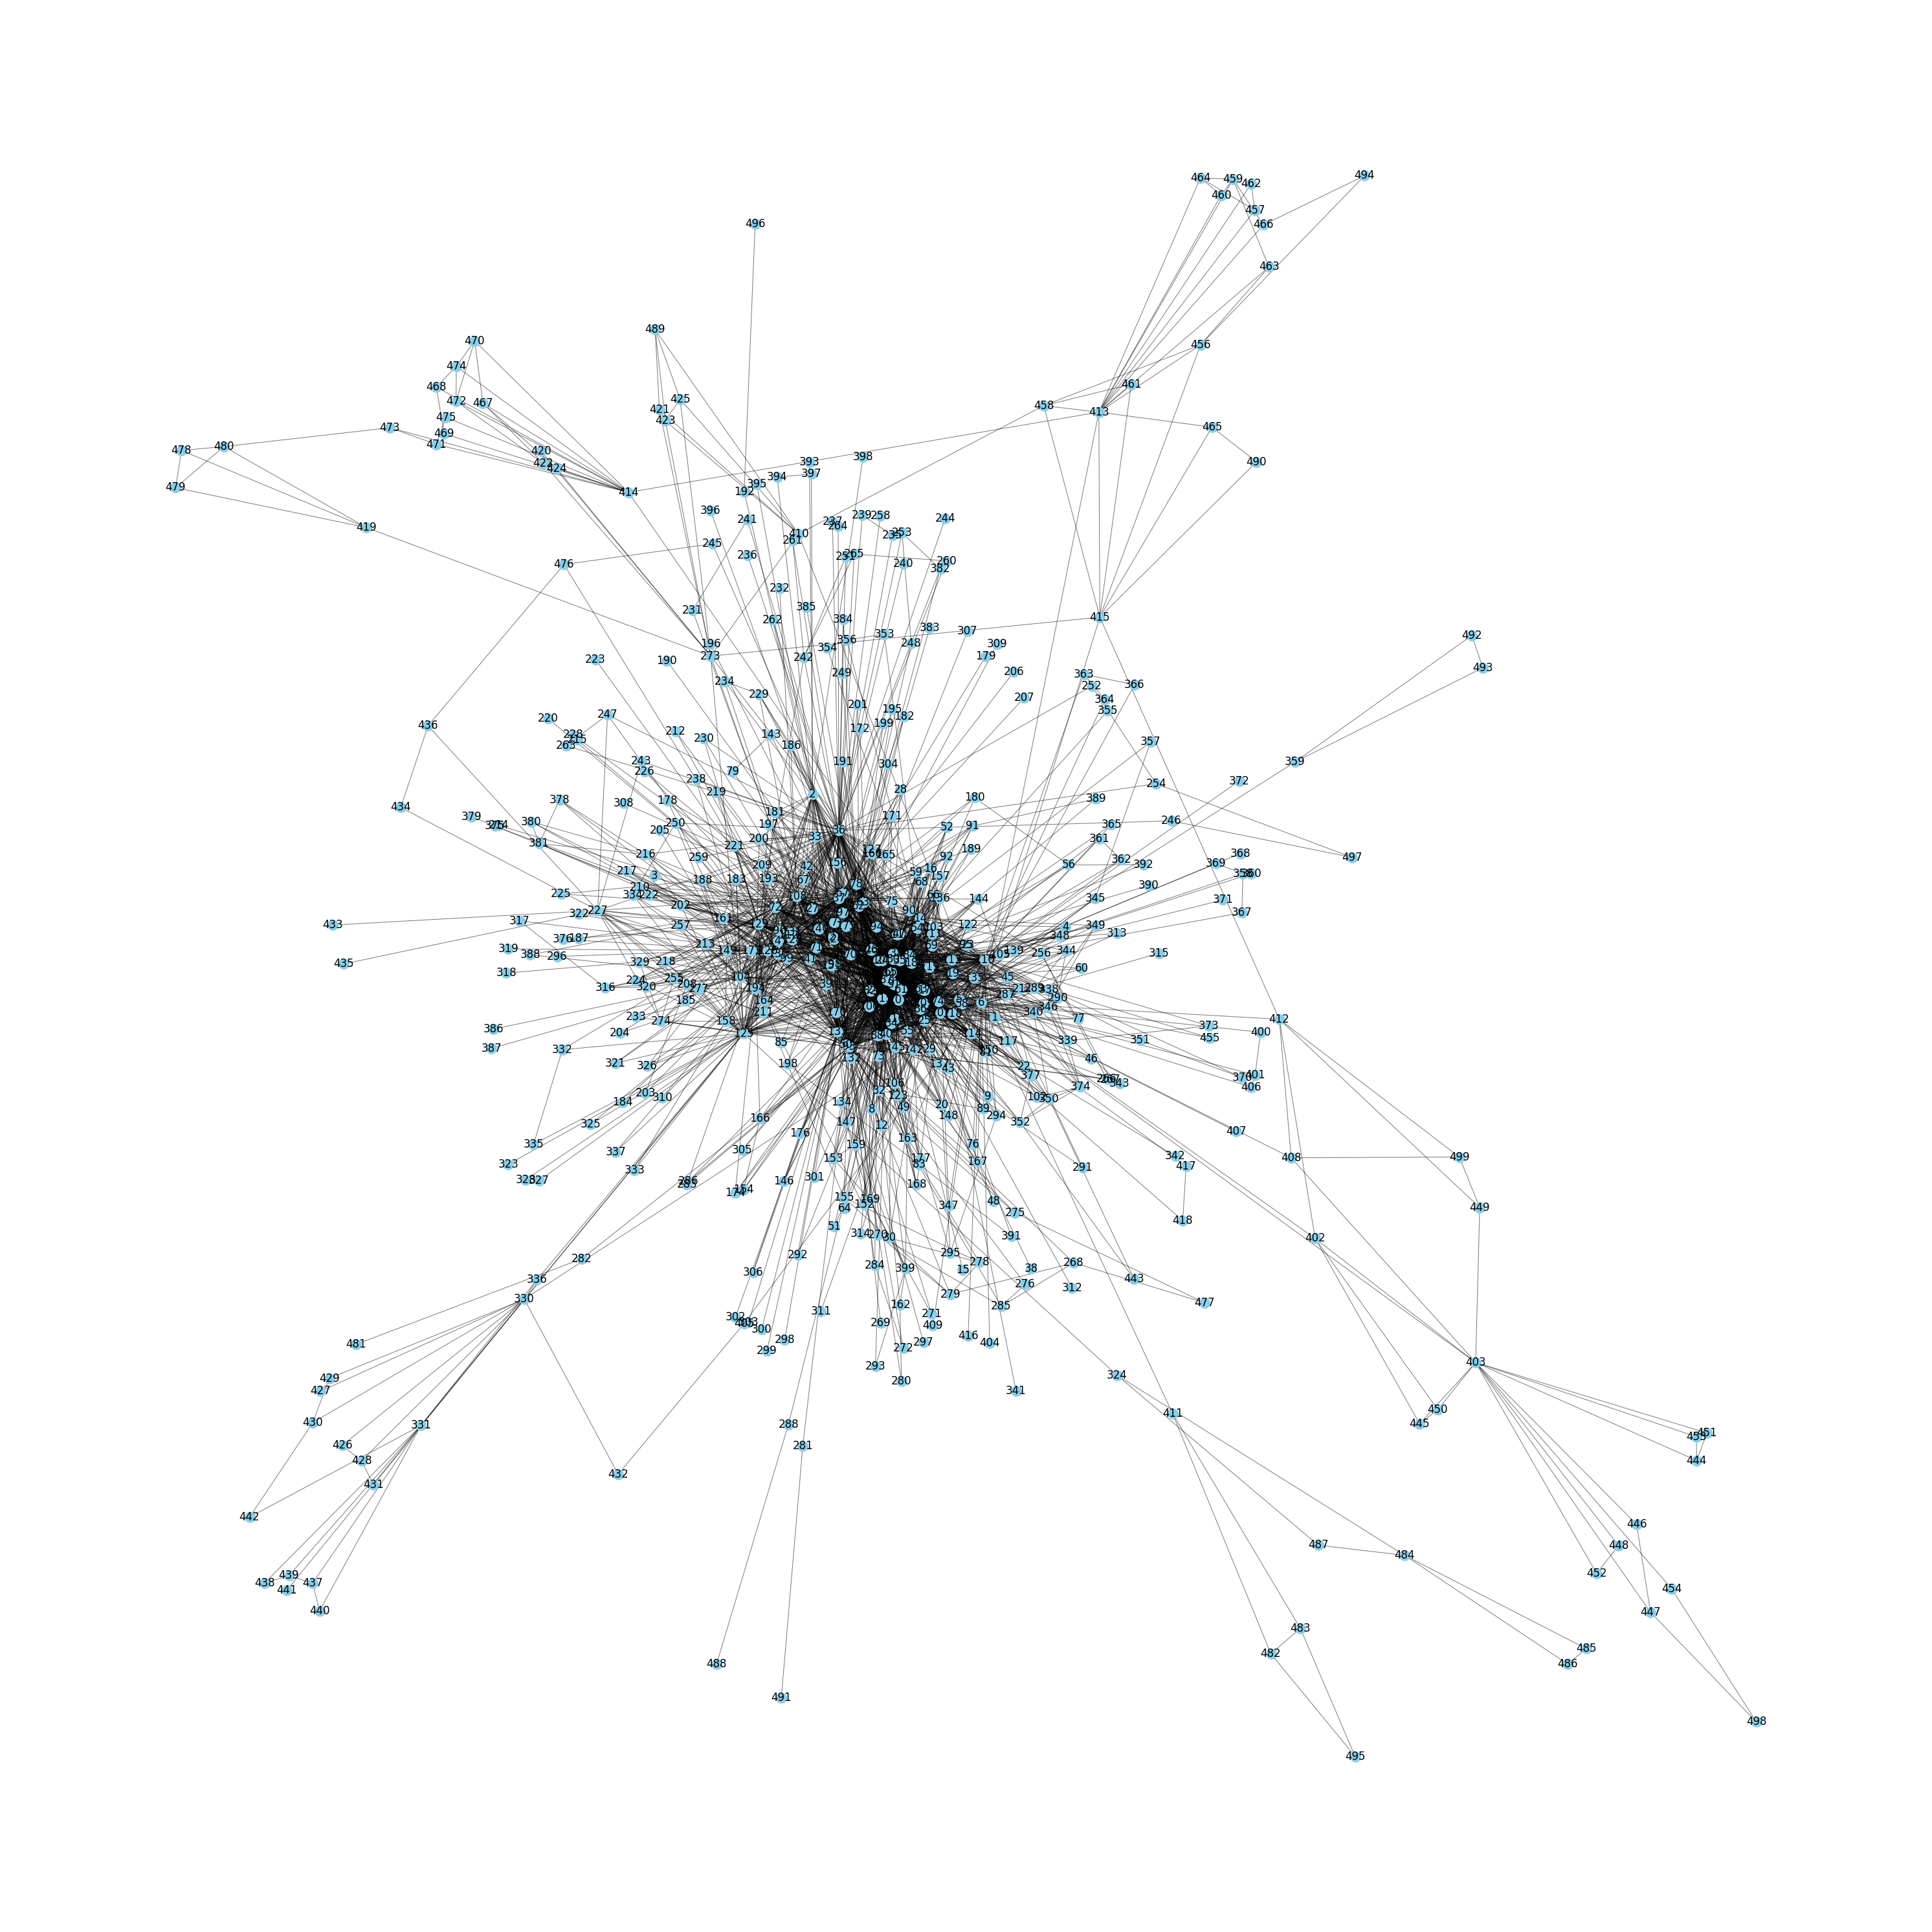

In [6]:
plot_large(G)

In [7]:
import numpy as np

res = 0
centrality = []
for i in range(1, 1001):
    try:
        centrality = list(nx.eigenvector_centrality(G, max_iter=i).values())
        mean_centrality = np.mean(centrality)

        res = mean_centrality
        print(f'iter={i} -> mean={mean_centrality:.6f}')
        break

    except nx.PowerIterationFailedConvergence:
        print(f'iter={i} -> did not converge')

iter=1 -> did not converge
iter=2 -> did not converge
iter=3 -> did not converge
iter=4 -> did not converge
iter=5 -> did not converge
iter=6 -> did not converge
iter=7 -> did not converge
iter=8 -> did not converge
iter=9 -> did not converge
iter=10 -> did not converge
iter=11 -> mean=0.022754


In [8]:
print(f'{res:0.2f}')

0.02


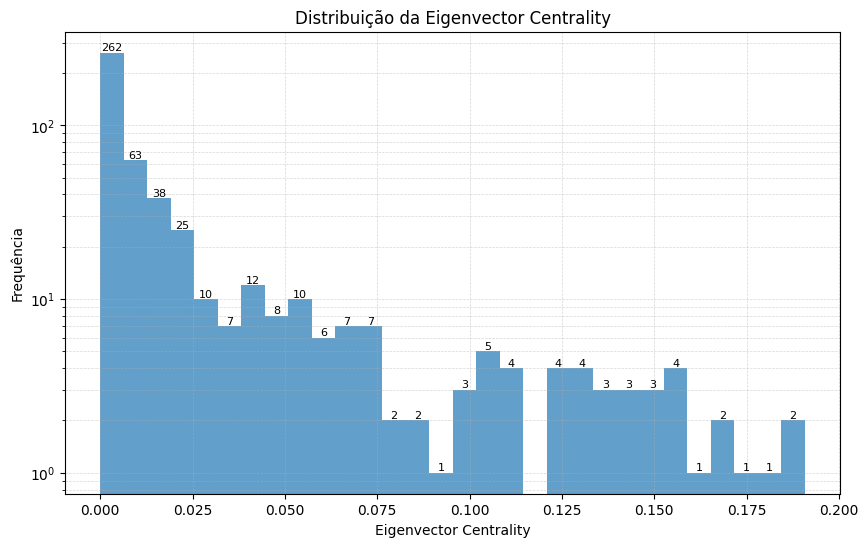

In [9]:
plt.figure(figsize=(10, 6))

# Captura das barras
counts, bins, patches = plt.hist(centrality, bins=30, alpha=0.7, label='Distribuição')

for count, patch in zip(counts, patches):
    if count > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        plt.text(x, y, f'{int(count)}', ha='center', va='bottom', fontsize=8)

plt.xlabel('Eigenvector Centrality')
plt.ylabel('Frequência')
plt.title('Distribuição da Eigenvector Centrality')

plt.yscale('log')

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

plt.show()

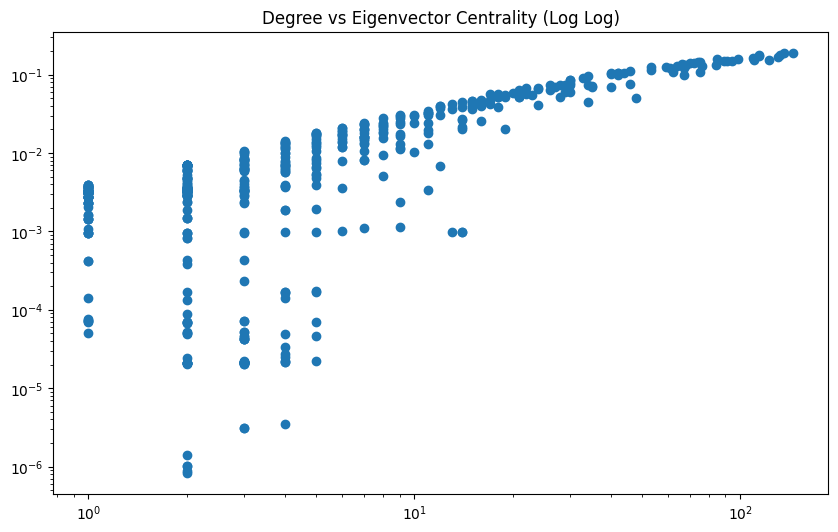

In [10]:
degree = [d for _, d in G.degree()]
plt.figure(figsize=(10, 6))
plt.title('Degree vs Eigenvector Centrality (Log Log)')
plt.scatter(degree, centrality)
plt.xscale('log')
plt.yscale('log')

# Hamsterster

Loading data from `./data/raw/hamsterster.txt`

## Análise

Na rede Hamsterster, a correlação de 0.8 entre grau e betweenness centrality 
indica que os nós mais conectados tendem também a intermediar os caminhos mais 
curtos da rede, exercendo assim maior controle sobre o fluxo de informação. 
No entanto, o gráfico log-log revela que essa relação não é determinística: 
nós de baixo grau apresentam variação de betweenness de até oito ordens de grandeza, 
evidenciando a existência de pontes estruturais com poucas conexões mas papel crítico 
na conectividade da rede. Ignorá-los representaria um risco significativo em cenários de falha.

In [11]:
G = nx.read_adjlist('data/raw/hamsterster.txt', nodetype=int)
G = normalize_data(G)

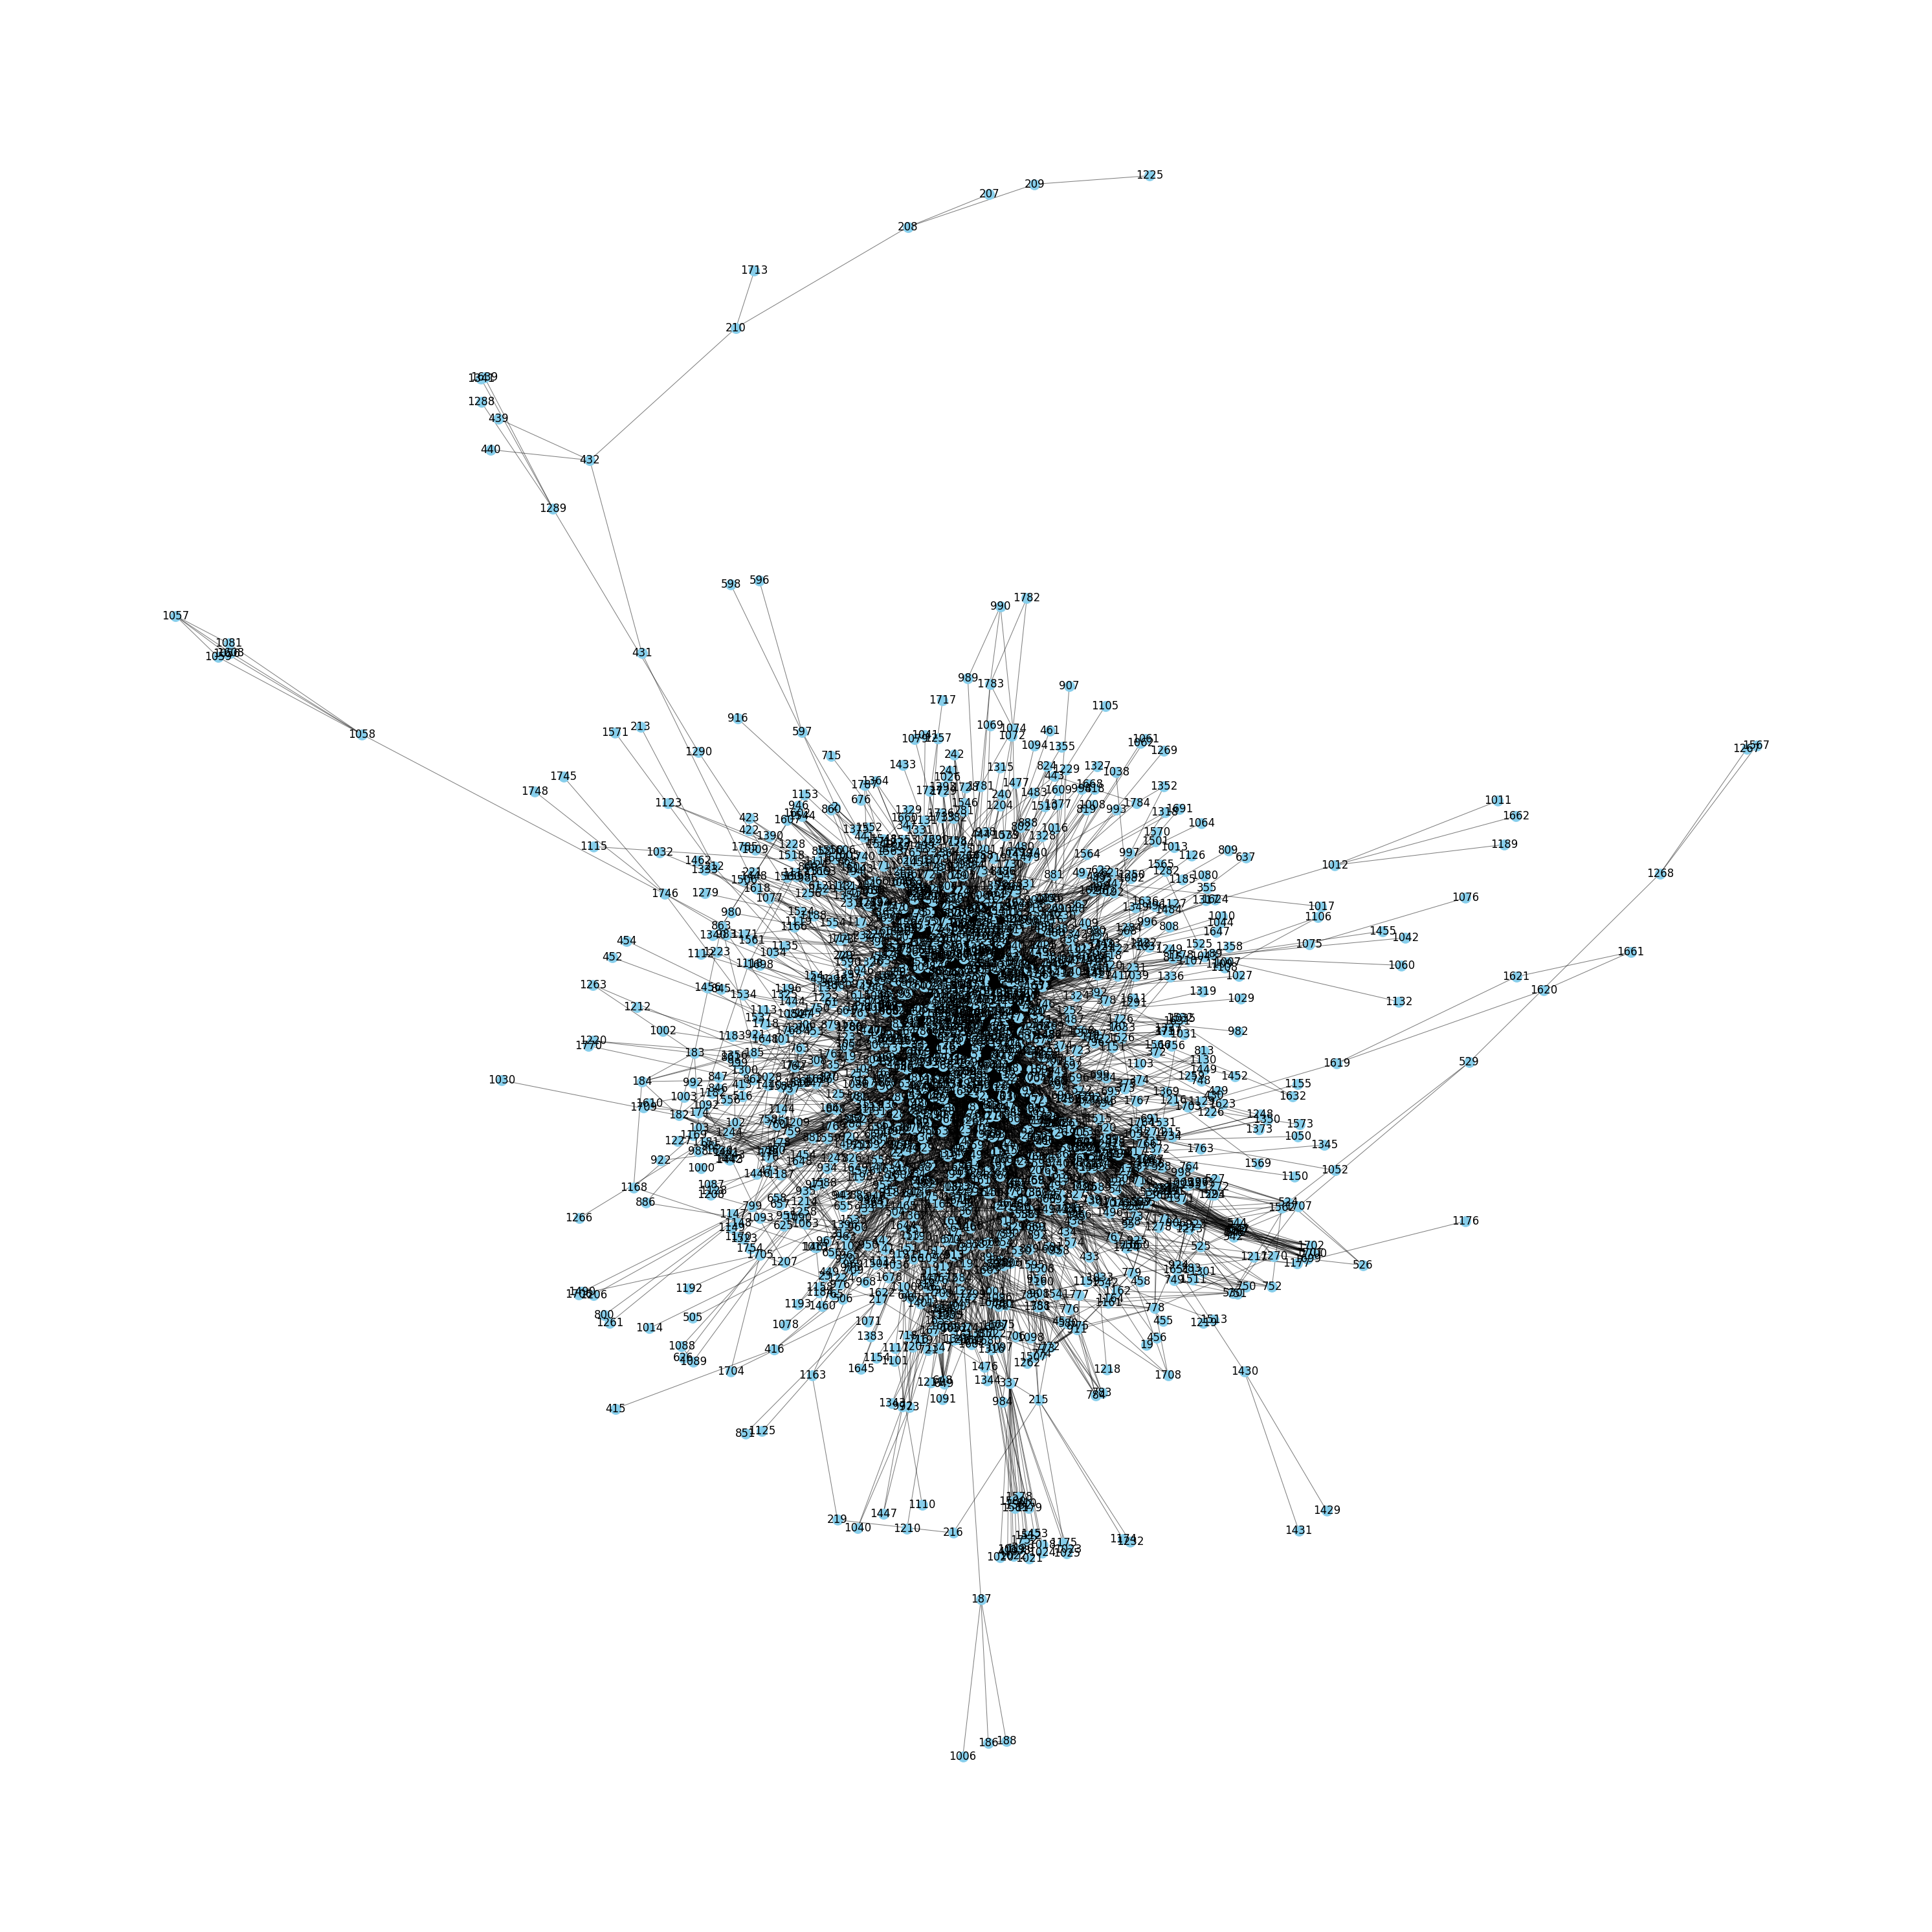

In [12]:
plot_large(G)

In [13]:
betweenness_centrality = list(nx.betweenness_centrality(G).values())
degree = [d for _, d in G.degree()]

In [14]:
from scipy.stats import pearsonr
r = pearsonr(betweenness_centrality, degree)
print(f'{r.statistic:0.1f}')

0.8


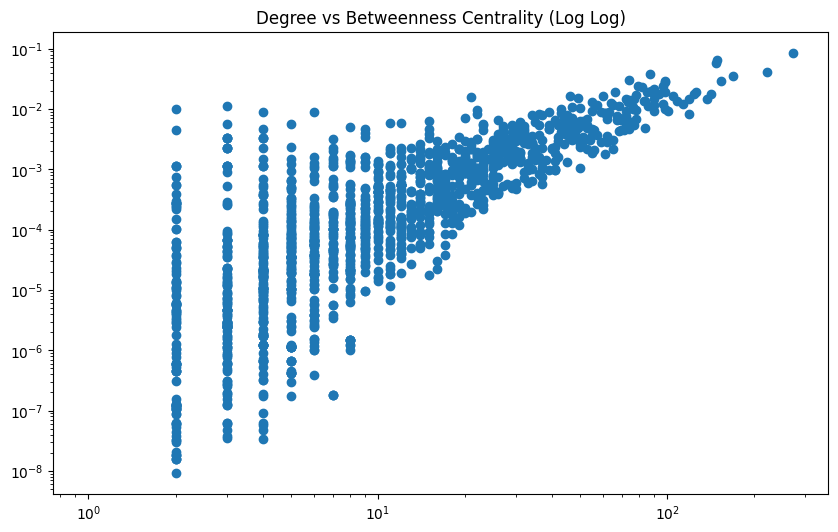

In [15]:
plt.figure(figsize=(10, 6))
plt.title('Degree vs Betweenness Centrality (Log Log)')
plt.scatter(degree, betweenness_centrality)
plt.xscale('log')
plt.yscale('log')

# Jazz

Loading data from `./data/raw/jazz.txt`

## Análise

A rede Jazz apresenta dois clusters densamente conectados, o que explica a
correlação moderada de 0.7 entre k-core e closeness centrality. Embora nós 
no núcleo de cada cluster apresentem alta closeness dentro de sua comunidade,
sua proximidade global é limitada pela distância estrutural entre os grupos. 
Os nós mais críticos da rede são aqueles que, com k-core intermediário, 
mantêm closeness global elevado, indicando seu papel como pontes entre as duas comunidades. 
A remoção desses nós não apenas reduz a influência local, mas potencialmente fragmenta a 
rede em dois componentes desconexos.

In [16]:
G = nx.read_adjlist('data/raw/jazz.txt', nodetype=int)
G = normalize_data(G)

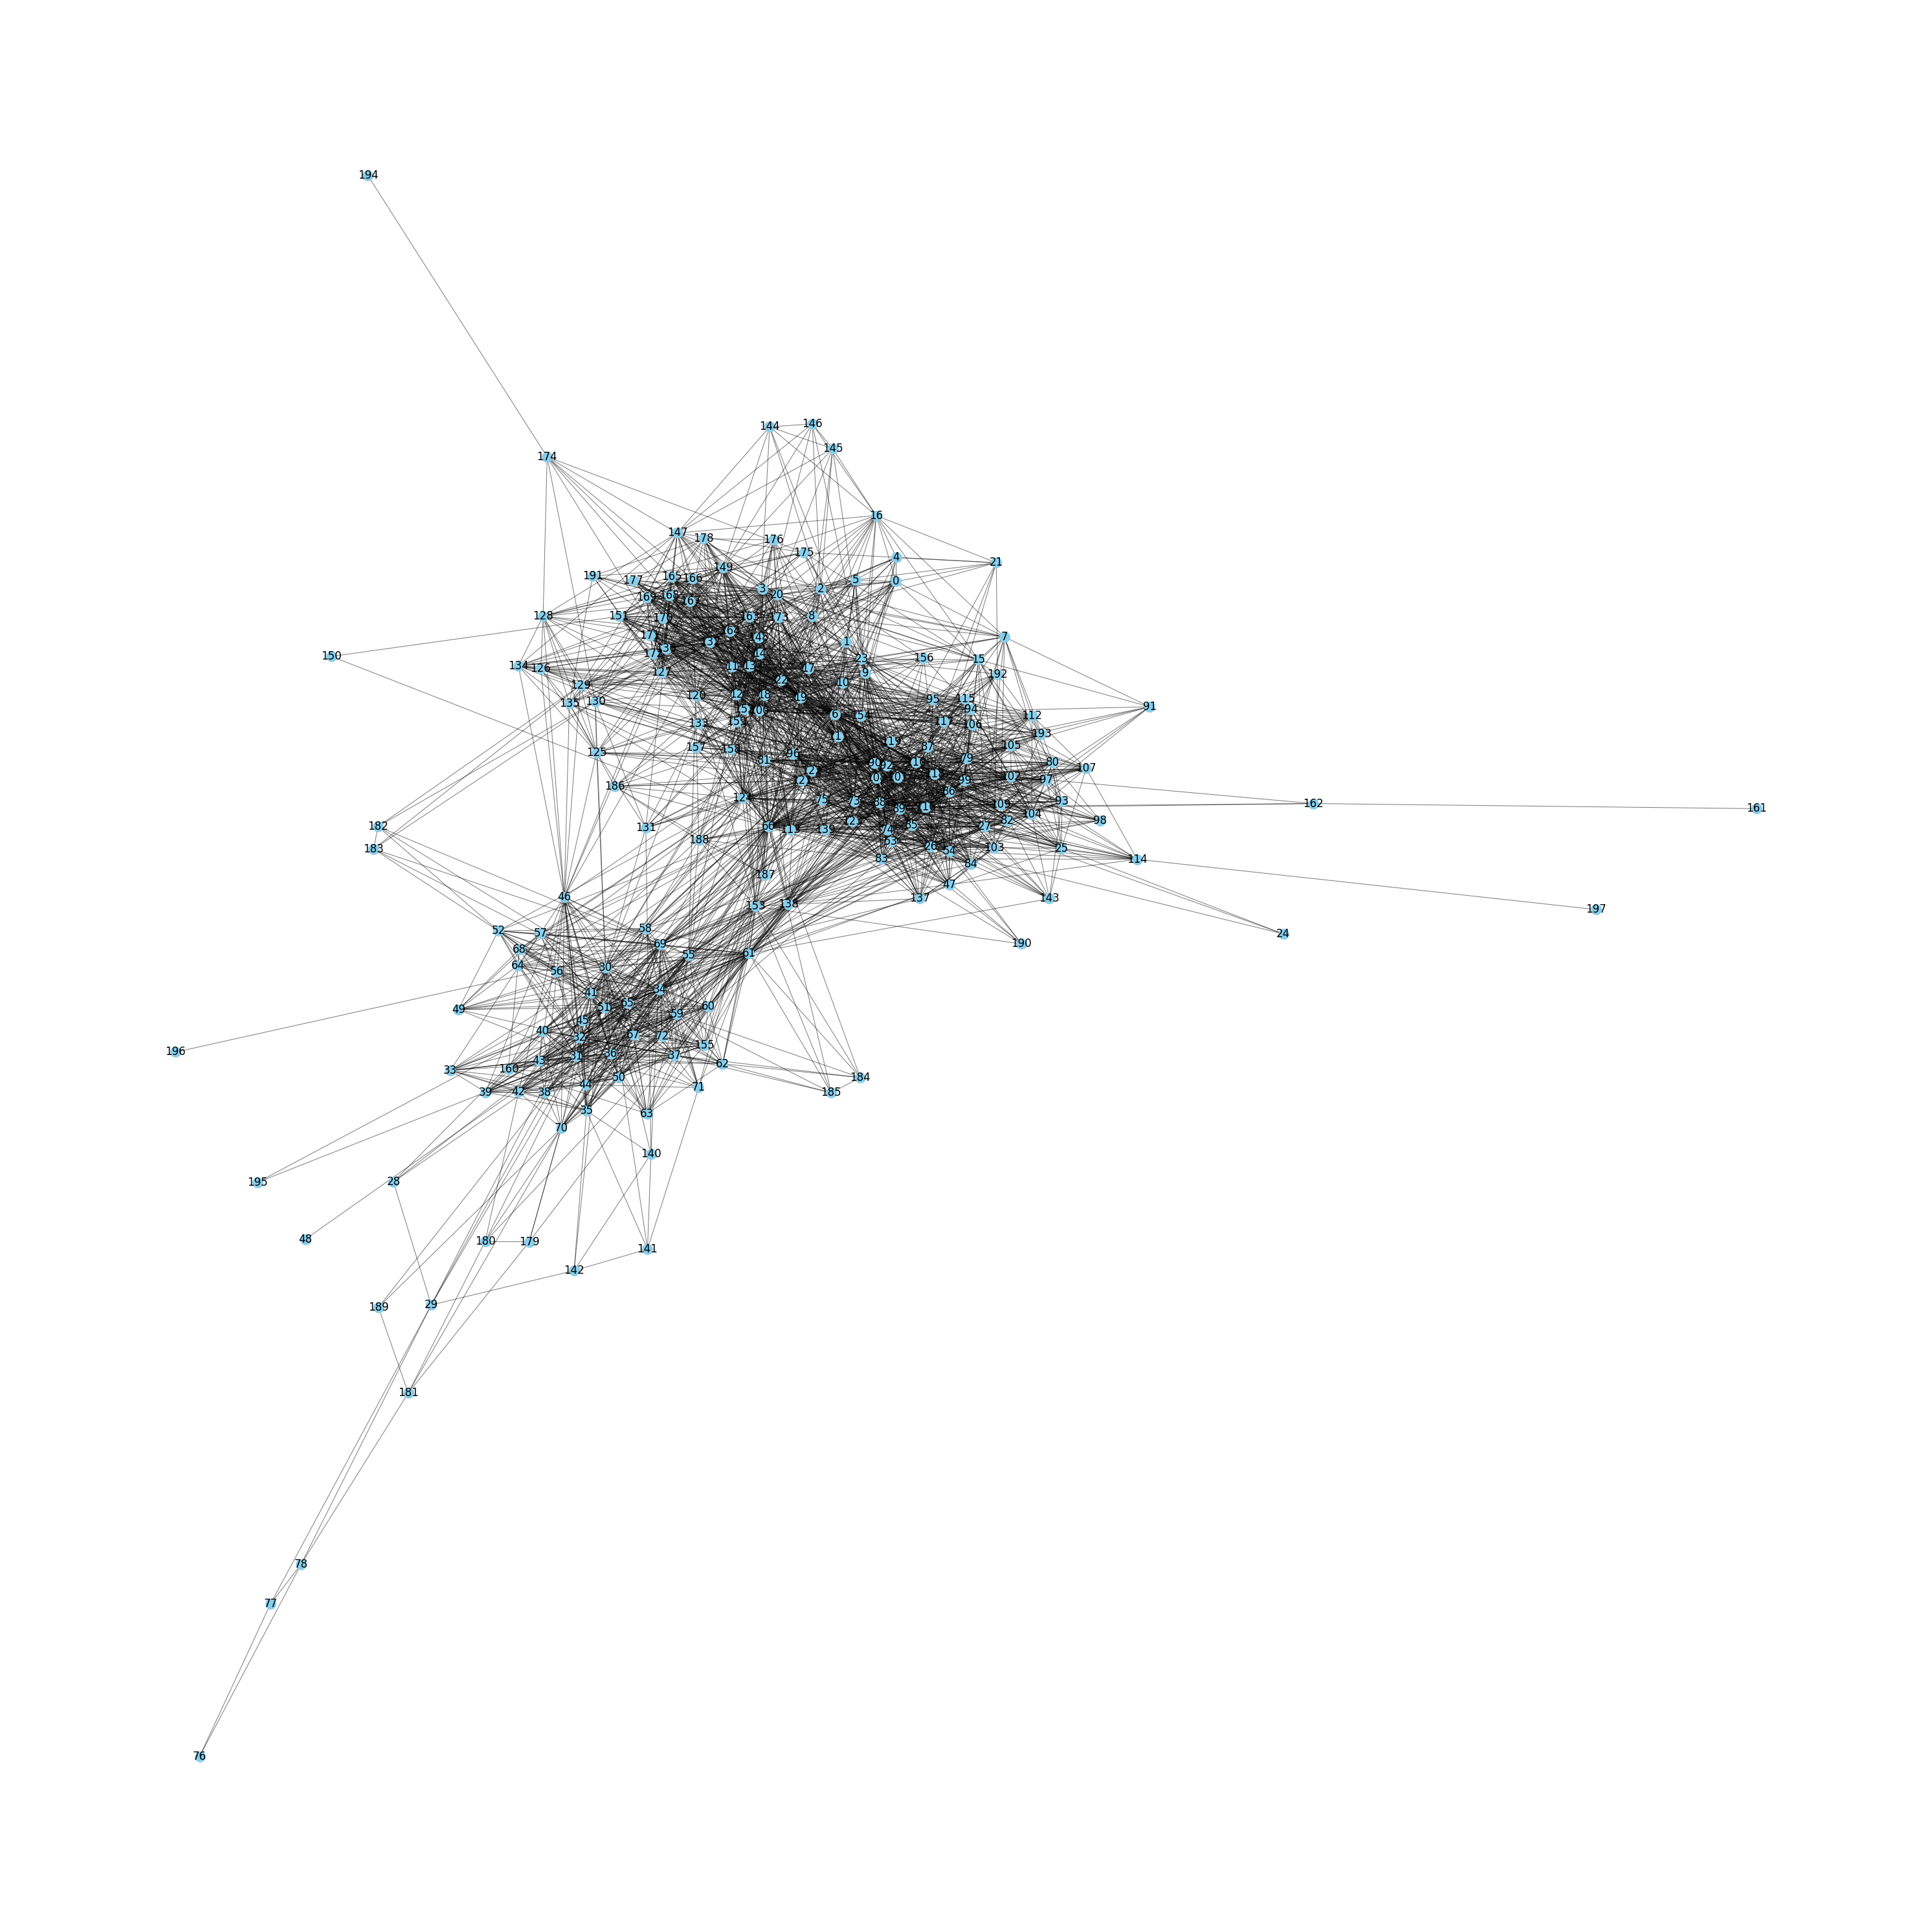

In [17]:
plot_large(G)

In [18]:
closeness_centrality = list(nx.closeness_centrality(G).values())
kcore = list(nx.core_number(G).values())

In [19]:
from scipy.stats import spearmanr

rho, _ = spearmanr(closeness_centrality, kcore)

In [20]:
print(f'{rho:0.1f}')

0.7


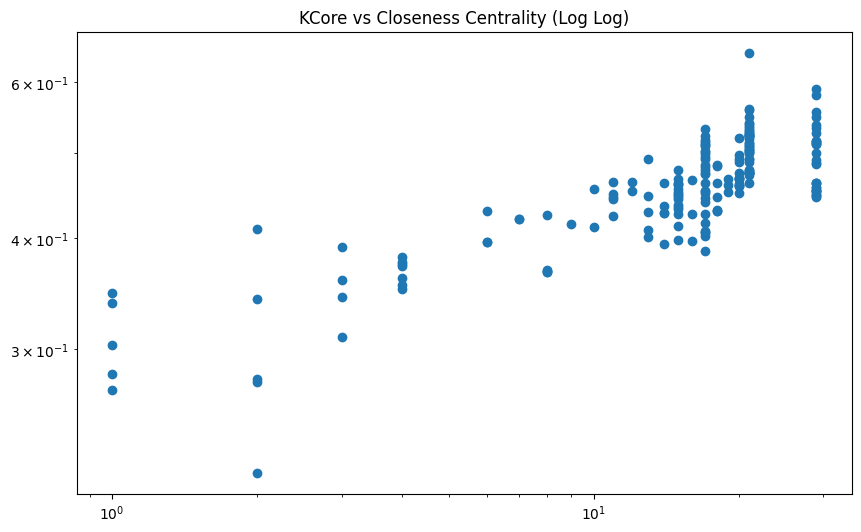

In [21]:
plt.figure(figsize=(10, 6))
plt.title('KCore vs Closeness Centrality (Log Log)')
plt.scatter(kcore, closeness_centrality)
plt.xscale('log')
plt.yscale('log')